In [603]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [604]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [605]:
from src import config

In [606]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [607]:
import random, numpy as np, matplotlib.pyplot as plt

In [608]:
random.seed(42)

### ConvEncoder

In [609]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.Flatten()
        )
        # 128 channels * 8 height * 12 width = 12288
        self.flattened_size = 128 * 8 * 12
        
        self.mu_layer = nn.Linear(self.flattened_size, latent_dim)
        self.logvar_layer = nn.Linear(self.flattened_size, latent_dim)
        
    def forward(self, x):
        h = self.net(x) # TODO: i dont understand the syntax here
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar       

### ConvDecoder

In [610]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.flattened_size = 128 * 8 * 12
        self.fc = nn.Linear(latent_dim, self.flattened_size)
        
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 8, 12)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)), # -> 16 x 23
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1, 1)), # -> 32 x 46
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)),  # -> 64 x 91
            nn.Sigmoid() 
        )
        
    def forward(self, z):
        h = self.fc(z)
        return self.net(h)

### Vanilla/Basic VAE

In [611]:
class VanillaVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.encoder = Encoder(
            latent_dim=cfg.LATENT_DIM
        )
        self.decoder = Decoder(
            latent_dim=cfg.LATENT_DIM
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
      x_recon = self.decoder(z)
      return x_recon
  
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### Dataset Class

In [612]:
class AudioSpectrogramDataset(Dataset):
    def __init__(self, dataset_dir, expected_shape=(config.INPUT_HEIGHT, config.INPUT_WIDTH), add_channel_dim=False):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.file_paths = sorted(self.dataset_dir.rglob("*npy"))
        self.expected_shape = expected_shape
        self.add_channel_dim = add_channel_dim
        self.global_min = -80.0
        self.global_max = 0.0
        
        # mins, maxs = [], []
        # for fp in self.file_paths[:200]:
        #     x = np.load(fp)
        #     mins.append(x.min())
        #     maxs.append(x.max())

        # print("min of mins:", min(mins))
        # print("max of maxs:", max(maxs))
        # print("avg min:", sum(mins)/len(mins))
        # print("avg max:", sum(maxs)/len(maxs))
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        x = np.load(file_path)
        x = (x - self.global_min) / (self.global_max - self.global_min)
        # x = np.clip(x, 0.0, 1.0)
        x = torch.tensor(x, dtype=torch.float32)
        if self.add_channel_dim: x = x.unsqueeze(0)
        
        return x, str(file_path)

## Activating GPU

In [613]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [614]:
device

device(type='cuda')

## Train and Test Data Preparation

In [615]:
npy_dir = Path("../..") / config.FEATURES_DIR

In [616]:
dataset = AudioSpectrogramDataset(dataset_dir=npy_dir)

In [617]:
BATCH_SIZE = 32

In [618]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [619]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [620]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=config.SHUFFLE)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [621]:
len(train_dataset), len(test_dataset)

(2000, 500)

## Training and Evaluating

In [622]:
def vae_loss(x_hat, x, beta, mu, logvar, epoch): # required for evaluation
    # recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    beta = min(1.0, epoch / 10)
    total = recon + beta * kl # TODO: use beta when and why?
    
    return total, recon, kl

In [623]:
def train_one_epoch(model, loader, optimizer, beta, epoch, device=device):
    model.train()
    total_sum = recon_sum = kl_sum = n = 0
    
    for x, _ in loader:
        x = x.to(device)
        x = x.unsqueeze(1)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n += x.size(0) # TODO: = 1 because channel?  
              
    train_total = total_sum / max(n, 1)
    train_recon = recon_sum / max(n, 1)
    train_kl = kl_sum / max(n, 1)
    
    return {
        "loss": train_total,
        "recon": train_recon,
        "kl": train_kl
    }

In [624]:
def evaluate(model, loader, beta, epoch, device=device):
    model.eval()
    total_sum = recon_sum = kl_sum = n = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
            
            total_sum += loss.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += x.size(0)

    test_total = total_sum / max(n, 1)
    test_recon = recon_sum / max(n, 1)
    test_kl = kl_sum / max(n, 1)
    
    return {
        "loss": test_total,
        "recon": test_recon,
        "kl": test_kl
    }

In [625]:
def train_vae(model, train_loader, test_loader, optimizer, beta, device=device):
    history = {"train_total": [], "test_total": [],
               "train_recon": [], "test_recon": [],
               "train_kl": [], "test_kl": []}
    for epoch in range(config.EPOCHS):
        train_stats = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, beta=beta, epoch=epoch, device=device)
        test_stats = evaluate(model=model, loader=test_loader, beta=beta, epoch=epoch, device=device)
        train_total = train_stats["loss"]
        test_total = test_stats["loss"]
        train_recon = train_stats["recon"]
        test_recon = test_stats["recon"]
        train_kl = train_stats["kl"]
        test_kl = test_stats["kl"]
        history["train_total"].append(train_total)
        history["test_total"].append(test_total)
        history["train_recon"].append(train_recon)
        history["test_recon"].append(test_recon)
        history["train_kl"].append(train_kl)
        history["test_kl"].append(test_kl)
        print(
            f"epoch {epoch:02d} | "
            f"train_total={train_total:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | "
            f"test_total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f}"
        )
        
    return history

In [626]:
def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_total"], label="train total")
    plt.plot(history["test_total"], label="test total")
    plt.plot(history["train_recon"], label="train recon")
    plt.plot(history["test_recon"], label="test recon")
    plt.plot(history["train_kl"], label="train kl")
    plt.plot(history["test_kl"], label="test kl")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Single Iteration Model

In [627]:
model = VanillaVAE(cfg=config).to(device)

In [628]:
model

VanillaVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=12288, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=12288, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=12288, bias=True)
    (net): Sequential(
     

In [629]:
optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [630]:
history = train_vae(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, beta=50.0, device=device)

epoch 00 | train_total=8.1578 recon=8.1578 kl=2699.6152 | test_total=6.8039 recon=6.8039 kl=12.0453
epoch 01 | train_total=4.1996 recon=3.7674 kl=4.3215 | test_total=3.6401 recon=3.3760 kl=2.6418
epoch 02 | train_total=3.2124 recon=2.8197 kl=1.9635 | test_total=3.0079 recon=2.6409 kl=1.8348
epoch 03 | train_total=2.9078 recon=2.4499 kl=1.5263 | test_total=2.7927 recon=2.3829 kl=1.3663
epoch 04 | train_total=2.7776 recon=2.2811 kl=1.2414 | test_total=2.7274 recon=2.2323 kl=1.2377
epoch 05 | train_total=2.6951 recon=2.1761 kl=1.0379 | test_total=2.6233 recon=2.1340 kl=0.9786
epoch 06 | train_total=2.6391 recon=2.1103 kl=0.8814 | test_total=2.5924 recon=2.0651 kl=0.8788
epoch 07 | train_total=2.5928 recon=2.0572 kl=0.7650 | test_total=2.5520 recon=1.9982 kl=0.7911
epoch 08 | train_total=2.5656 recon=2.0261 kl=0.6743 | test_total=2.5287 recon=2.0188 kl=0.6374
epoch 09 | train_total=2.5369 recon=1.9871 kl=0.6110 | test_total=2.5128 recon=1.9865 kl=0.5848
epoch 10 | train_total=2.5211 recon=

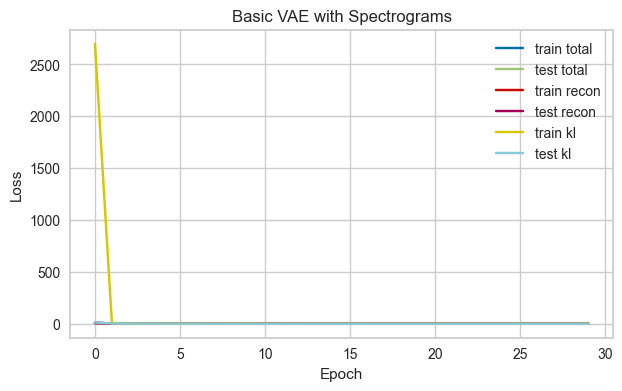

In [631]:
plot_history(history, "Basic VAE with Spectrograms")

## Extract Latent Features & Lyric Embeddings

In [632]:
def show_reconstructions(model, dataset, n=10, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    
    with torch.no_grad():
        for i in range(n):
            # Get a real sample
            print(dataset[i][1])
            x = dataset[i][0].unsqueeze(0).unsqueeze(0).to(device)
            x_hat, _, _ = model(x)
            
            # Original Spectrogram
            img_org = x.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_org, origin='lower', aspect='auto')
            axes[i, 0].set_title(f"Original {i}")
            
            # Reconstructed Spectrogram
            img_recon = x_hat.squeeze().cpu().numpy()
            axes[i, 1].imshow(img_recon, origin='lower', aspect='auto')
            axes[i, 1].set_title(f"Reconstructed {i}")
            
    plt.tight_layout()
    plt.show()

..\..\data\features\MT0000353361_clip_4.npy
..\..\data\features\MT0011963777_clip_7.npy


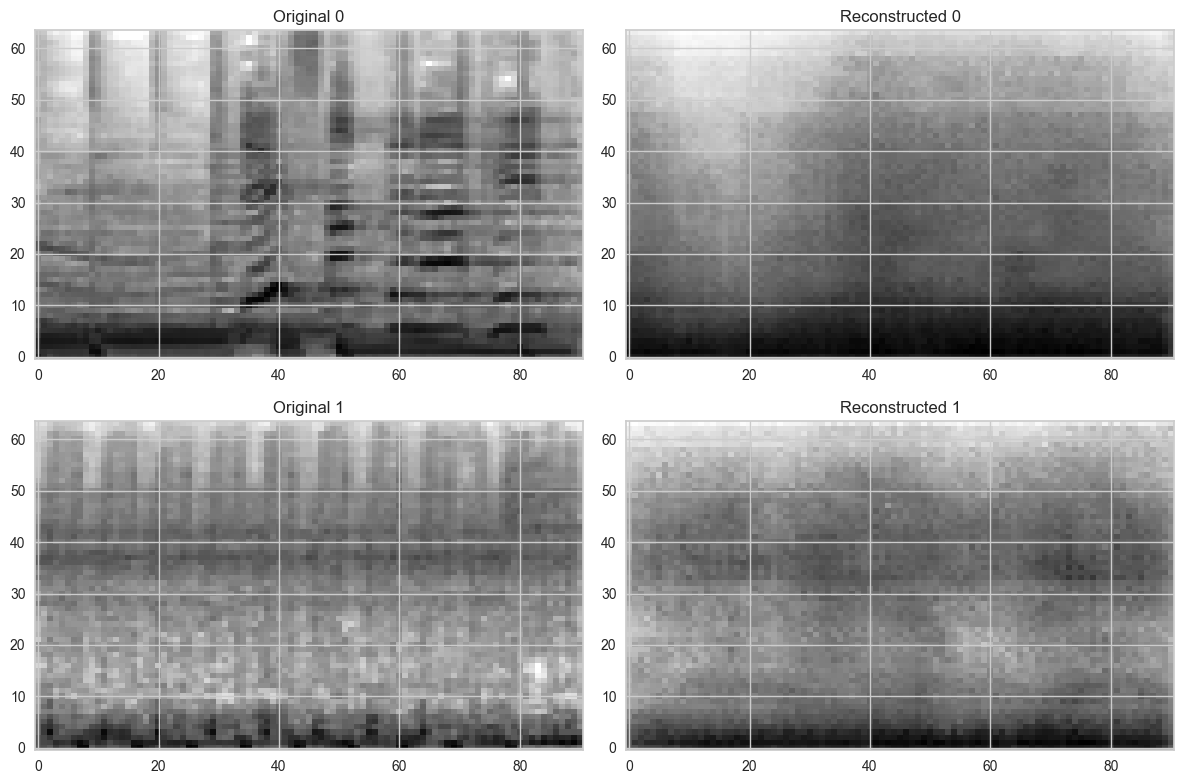

In [633]:
show_reconstructions(model=model, dataset=train_dataset, n=2)

In [634]:
def extract_latents_with_names(model, loader, device=device):
    model.eval()
    latents = []
    names = []
    with torch.no_grad():
        for x, filenames in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            mu, _ = model.encoder(x)
            latents.append(mu.cpu().numpy())
            names.extend(filenames)
            
    return np.concatenate(latents,axis=0), names

In [635]:
latent_vecs1,audio_names1 = extract_latents_with_names(model=model, loader=train_loader)
latent_vecs2,audio_names2 = extract_latents_with_names(model=model, loader=test_loader)
latent_vecs = np.concatenate([latent_vecs1, latent_vecs2], axis=0)
audio_names = np.concatenate([audio_names1, audio_names2], axis=0)

print(f"Train shape: {latent_vecs1.shape} ")
print(f"Test shape:  {latent_vecs2.shape} ")
print(f"Total shape: {latent_vecs.shape} ")

Train shape: (2000, 32) 
Test shape:  (500, 32) 
Total shape: (2500, 32) 


In [636]:
LYRICS_DATASET_ROOT = Path("C:/Users/User/Downloads/VAE project/MERGE_Lyrics_Balanced") 
LYRIC_FEATURES_DIR = root / "data" / "lyric_features"
print(LYRIC_FEATURES_DIR)

c:\Users\User\Downloads\VAE project\vae-audio-clustering\data\lyric_features


In [637]:
X_hybrid = []

for i, full_name in enumerate(audio_names):
    # 1. Get the parent stem (remove _clip_x)
    parent_stem = full_name.split('_')[0]
    parent_stem = parent_stem.split('\\')[-1]
    # 2. Get the audio vector for this specific row
    z_audio = latent_vecs[i] # Size 32
    
    # 3. Load the corresponding lyric vector
    # We use the parent_stem to find the lyric file
    lyric_path = LYRIC_FEATURES_DIR / f"{parent_stem}.npy"
    # print(lyric_path)
    
    if lyric_path.exists():
        z_text = np.load(lyric_path) # Size 384
        
        # 4. Concatenate: [32] + [786] = [800]
        z_combined = np.concatenate([z_audio, z_text])
        X_hybrid.append(z_combined)
    else:
        print(f"Warning: No lyrics for {parent_stem}")

X_hybrid = np.array(X_hybrid)

In [638]:
X_hybrid.shape

(2500, 800)

In [639]:
# X_hybrid=latent_vecs
# print(X_hybrid.shape)

## K-means of Latent Features (Primary Model for Easy Task)

In [640]:
X_hybrid

array([[ 0.38469392, -0.17114128, -0.04178709, ...,  0.02844897,
        -0.03199083, -0.06600603],
       [ 0.10532673,  0.06822819,  0.18639025, ..., -0.02521317,
        -0.05500324, -0.04480439],
       [ 0.4752336 ,  0.05113827,  0.31446767, ..., -0.05039344,
        -0.00466915, -0.01963239],
       ...,
       [ 0.10464138, -0.00075012, -0.15533175, ...,  0.02894185,
         0.02254554, -0.02916163],
       [ 0.40768534,  0.08377598, -0.32921225, ..., -0.02295579,
        -0.0179954 , -0.01023202],
       [ 0.00375457,  0.15027846, -0.01022054, ...,  0.00310923,
         0.00230502, -0.02063657]], shape=(2500, 800), dtype=float32)

In [641]:
import pandas as pd
X_hybrid=pd.DataFrame(X_hybrid )
X_hybrid.head()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
0,0.384694,-0.171141,-0.041787,0.155597,1.074151,-0.318498,-0.409263,0.306189,0.340675,0.457944,...,-0.057026,-0.021930,0.048262,-0.000703,-0.006484,0.010804,-0.018876,0.028449,-0.031991,-0.066006
1,0.105327,0.068228,0.186390,0.132307,0.212141,-0.007396,-0.064534,0.507857,0.460079,0.075113,...,-0.043697,-0.031843,0.015620,-0.024418,-0.038777,0.021325,-0.063767,-0.025213,-0.055003,-0.044804
2,0.475234,0.051138,0.314468,0.420039,0.517133,0.227808,-0.030623,-0.066450,-0.663363,0.275004,...,-0.062322,-0.021701,0.043033,0.036607,-0.019394,-0.075176,-0.063009,-0.050393,-0.004669,-0.019632
3,-0.099176,0.088688,-0.426705,-0.036472,0.395642,0.198971,-0.032941,0.106117,-0.557709,-0.063582,...,-0.015831,0.054517,-0.020655,0.021873,0.004279,-0.018106,-0.075400,-0.042717,0.045850,-0.057012
4,0.184256,-0.351276,-0.252677,-0.080611,-0.025037,0.167437,-0.280716,0.423848,0.287851,0.323354,...,-0.044810,0.004044,0.050664,0.006895,0.003008,-0.040701,-0.026964,-0.004677,-0.009586,0.002625


In [642]:
X_hybrid.describe()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.071651,-0.002542,-0.095613,0.058830,0.435110,-0.100244,-0.293683,0.124242,-0.293006,-0.034445,...,-0.025838,-0.002853,0.012728,0.001246,-0.017044,-0.003480,-0.033128,-0.004572,-0.022492,-0.014866
std,0.334069,0.192205,0.301746,0.976431,0.972147,0.370067,0.557886,0.457947,0.972764,0.393709,...,0.031742,0.025370,0.033978,0.023234,0.016178,0.035347,0.025087,0.023957,0.031803,0.020952
min,-1.217578,-0.745273,-1.383879,-4.716218,-5.104771,-1.641330,-2.275809,-2.062342,-4.351166,-2.792304,...,-0.123760,-0.083610,-0.097509,-0.105466,-0.070846,-0.144655,-0.111684,-0.080749,-0.110829,-0.082614
25%,-0.135328,-0.120421,-0.276792,-0.647346,-0.014566,-0.323966,-0.623701,-0.128347,-0.909244,-0.254552,...,-0.047593,-0.019647,-0.009397,-0.013578,-0.027779,-0.026110,-0.050614,-0.020530,-0.043997,-0.028864
50%,0.041682,0.000945,-0.106990,-0.065110,0.458838,-0.047115,-0.203330,0.104835,-0.229513,0.000664,...,-0.027690,-0.002531,0.013122,0.001528,-0.017277,-0.003553,-0.034116,-0.005290,-0.024050,-0.014901
75%,0.283826,0.118216,0.078469,0.590402,1.005876,0.144517,0.097632,0.354142,0.379341,0.198714,...,-0.005309,0.013745,0.035835,0.017078,-0.006851,0.019857,-0.016724,0.011395,-0.002770,-0.000945
max,1.374188,0.929872,1.243795,4.719883,3.842881,1.470706,1.201352,2.730989,2.540001,1.549585,...,0.096007,0.081997,0.133241,0.082623,0.045397,0.119987,0.058392,0.082305,0.092216,0.053246


In [643]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

%matplotlib inline

In [644]:
track_inertia={}
silhouette={}
ch_index={}
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++', random_state=42)
    kmeans.fit(X_hybrid)
    track_inertia[k] = kmeans.inertia_
    silhouette[k] = silhouette_score(X_hybrid, kmeans.labels_) 
    ch_index[k] = calinski_harabasz_score(X_hybrid, kmeans.labels_)

<Axes: >

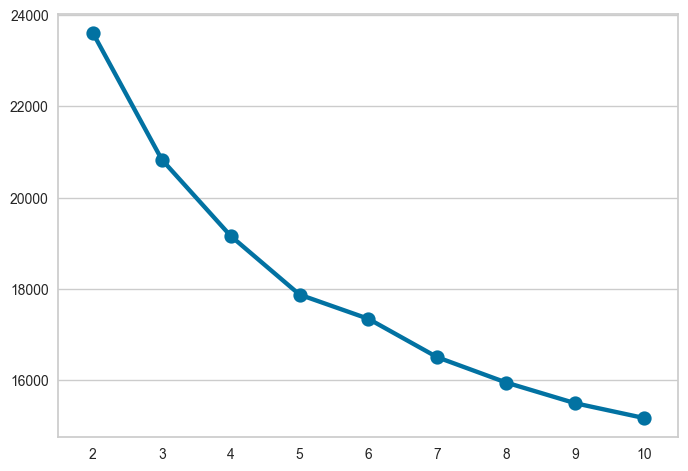

In [645]:
sns.pointplot(x = list(track_inertia.keys()), y = list(track_inertia.values()))

<Axes: >

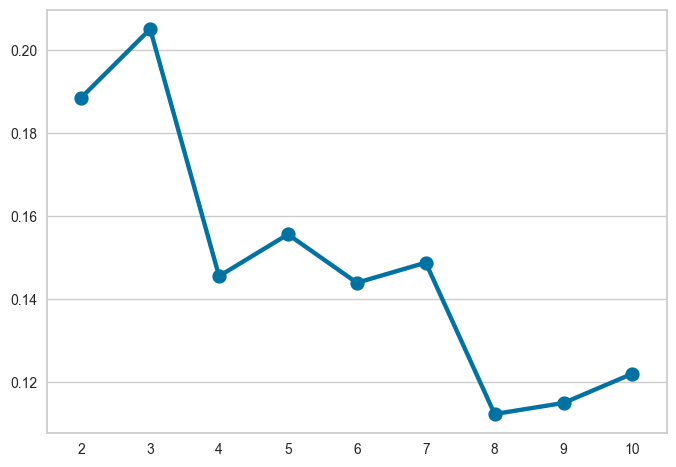

In [646]:
sns.pointplot(x = list(silhouette.keys()), y = list(silhouette.values()))

<Axes: >

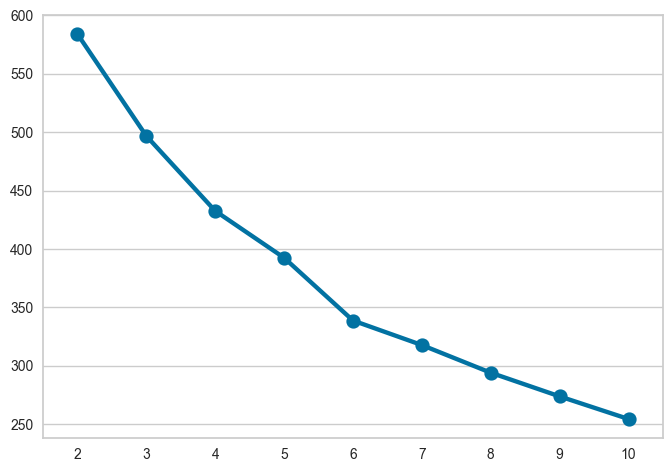

In [647]:
sns.pointplot(x = list(ch_index.keys()), y = list(ch_index.values()))

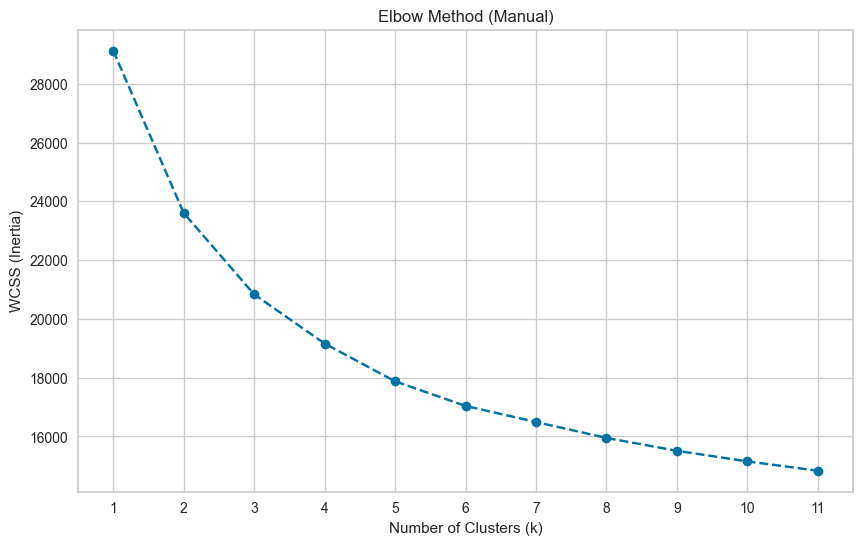

In [648]:
wcss = []
k_values = range(1, 12)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    km.fit(X_hybrid)
    wcss.append(km.inertia_) # inertia_ is the "WCSS" value you need for the elbow


plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Manual)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

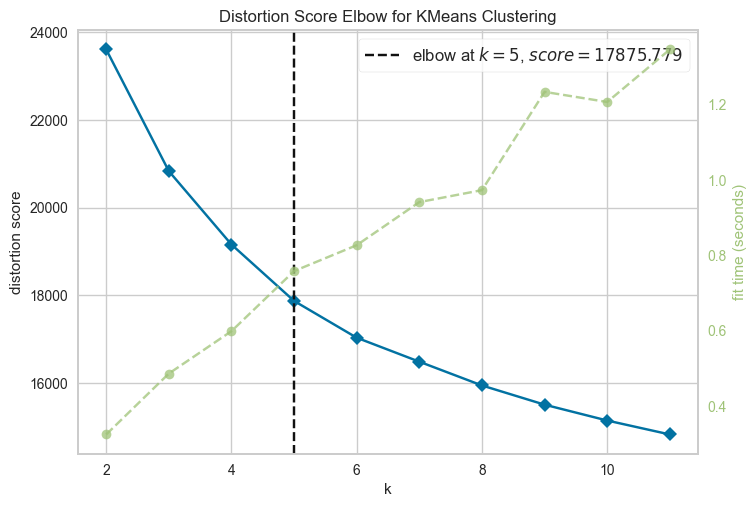

In [649]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model2 = KMeans(init='k-means++', random_state=0, n_init=10)

visualizer = KElbowVisualizer(model2, k=(2, 12), timings=True, force_model=True)

visualizer.fit(X_hybrid)        
visualizer.show()

optimal_k = visualizer.elbow_value_

In [650]:
optimal_k

np.int64(5)

In [651]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = optimal_k,init = "k-means++",max_iter = 300,n_init=10,random_state=0)
kmeans.fit(X_hybrid)
vae_clusters = kmeans.predict(X_hybrid)
vae_sil=silhouette_score(X_hybrid,kmeans.labels_)
print("WCSS for k: %d and Silhouette Score: %f"%(kmeans.inertia_,vae_sil))
print("calinski_harabasz_score: %f"%(calinski_harabasz_score(X_hybrid,kmeans.labels_)))

WCSS for k: 17875 and Silhouette Score: 0.154604
calinski_harabasz_score: 392.449707


## PCA + Kmeans (Baseline Model for Easy Task)

In [652]:
def loader_to_numpy(loader):
    xs = []
    for x,_ in loader:
        xs.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(xs)

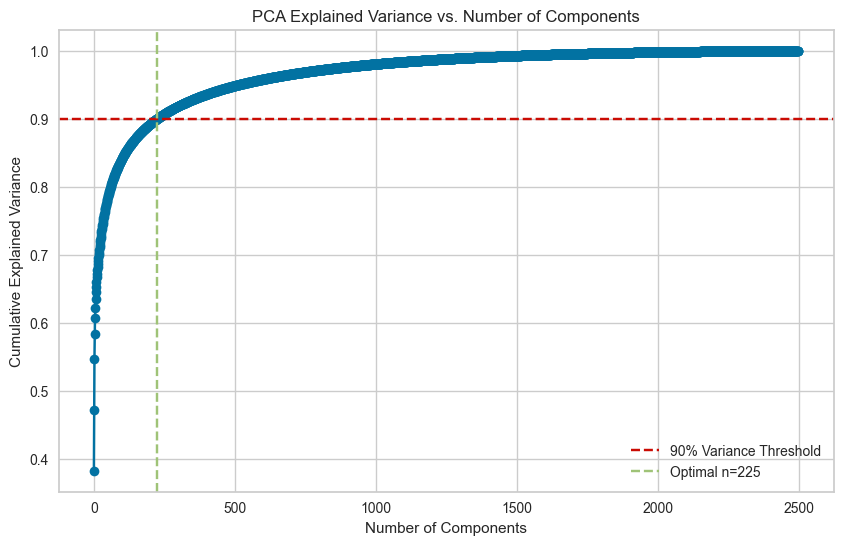

Optimal components for 90% variance: 225


In [653]:
from sklearn.decomposition import PCA

X_train = loader_to_numpy(train_loader)
X_test = loader_to_numpy(test_loader)

X_all = np.concatenate([X_train, X_test], axis=0)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca_full = PCA().fit(X_all)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
optimal_n = np.where(cumulative_variance >= 0.90)[0][0] + 1

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-') # removed 'loc'
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal n={optimal_n}')
plt.title('PCA Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f"Optimal components for 90% variance: {optimal_n}")

In [654]:
optimal_n

np.int64(225)

In [655]:
pca = PCA(n_components=optimal_n, random_state=42)
X_pca = pca.fit_transform(X_all)

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
pca_clusters = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, pca_clusters)
ch_idx = calinski_harabasz_score(X_pca, pca_clusters)

print(f"--- PCA + KMeans Baseline ---")
print(f"Silhouette Score: {round(sil, 4)}")
print(f"Calinski-Harabasz Index: {round(ch_idx, 4)}")

--- PCA + KMeans Baseline ---
Silhouette Score: 0.1743
Calinski-Harabasz Index: 485.4253


## Visualize t-sne for both models

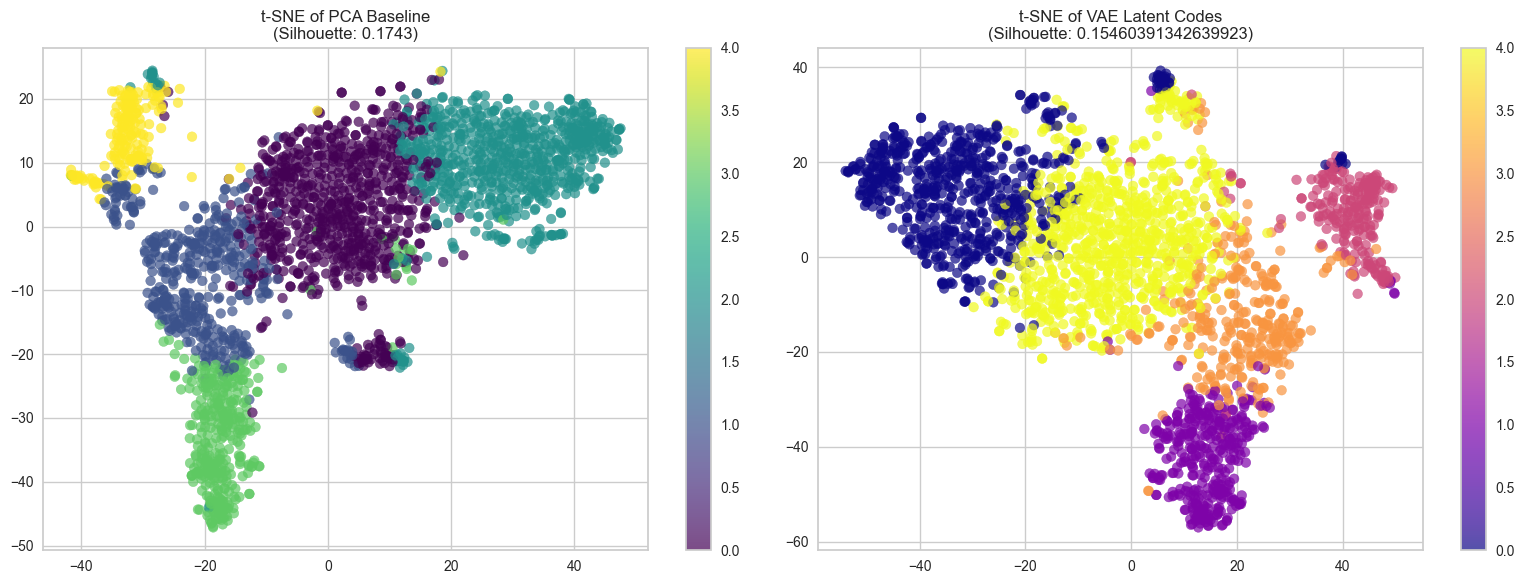

In [656]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(pca_latents, vae_latents, pca_clusters, vae_clusters):

    tsne_pca = TSNE(n_components=2, random_state=42).fit_transform(pca_latents)
    
    tsne_vae = TSNE(n_components=2, random_state=42).fit_transform(vae_latents)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter1 = ax1.scatter(tsne_pca[:, 0], tsne_pca[:, 1], c=pca_clusters, cmap='viridis', alpha=0.7)
    ax1.set_title(f"t-SNE of PCA Baseline\n(Silhouette: {round(sil, 4)})")
    fig.colorbar(scatter1, ax=ax1)
    
    scatter2 = ax2.scatter(tsne_vae[:, 0], tsne_vae[:, 1], c=vae_clusters, cmap='plasma', alpha=0.7)
    ax2.set_title(f"t-SNE of VAE Latent Codes\n(Silhouette: {vae_sil})")
    fig.colorbar(scatter2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

plot_tsne_comparison(X_pca, latent_vecs, pca_clusters, vae_clusters)